# Latent Dynamics Estimation on a Synthetic Generator
# 2.1. Synthetic generator on the two-sphere

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.spatial import procrustes

In [ ]:
### Fixes:
# 1. Changed the number of samples to reach T, instead of having N=T
# 2. Corrected the initial stationary distribution

# Parameters
mu    = np.array([0,0,1])
kappa = 0.5
sigma = 0.2
dt    = 0.01
T     = 100
d     = 2

def simulate_ou_on_sphere(mu = np.array([0,0,1]),
                          kappa: float = 0.5,
                          sigma: float = 0.2,
                          dt:float = 0.01,
                          T: int = 100,
                          d: int = 2):
    
    # Number of samples required to reach T
    N = int(T/dt) + 1

    # Generating the latent process Yt
    Y = np.zeros(shape=(N,d))
    Y[0] = np.random.multivariate_normal(mean=np.zeros(d), cov=(sigma**2/2*kappa) * np.eye(d))

    for t in range(1,N):
        xi = np.random.multivariate_normal(mean=np.zeros(d), cov=(np.eye(d)))
        Y[t] = np.exp(-kappa * dt) * Y[t-1] + np.sqrt(sigma**2/2*kappa * (1-np.exp(-2*kappa*dt))) * xi


    # Projecting onto the sphere with the exponential map
    X = np.zeros(shape=(N, d+1))

    Y_norm = np.linalg.norm(Y, axis=1)
    sinc = np.divide(np.sin(Y_norm), Y_norm, where=Y_norm!=0, out=np.ones_like(Y_norm))

    X[:,0] = sinc * Y[:,0]
    X[:,1] = sinc * Y[:,1]
    X[:,2] = np.cos(Y_norm)

    return X, Y

X, Y = simulate_ou_on_sphere(T=100)


In [24]:
# %matplotlib widget

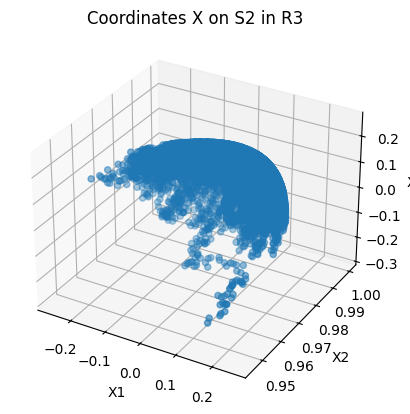

In [25]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
pts = np.column_stack((X[:, 0], X[:, 2], X[:, 1]))
cmap = plt.cm.viridis
norm = plt.Normalize(0, len(pts) - 2)

# for i in range(len(pts) - 1):
#     ax.plot(
#         pts[i:i+2, 0],
#         pts[i:i+2, 1],
#         pts[i:i+2, 2],
#         color=cmap(norm(i)),
#         linewidth=2,
#     )

ax.scatter(X[:, 0], X[:, 2], X[:, 1], s=20)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('X3')
ax.set_title('Coordinates X on S2 in R3')
#ax.view_init(elev=20, azim=60)
plt.show()

# 2.2.  Construction of the noisy high-dimensional observation

In [192]:
# D in [50, 100]
# sigma_eta in [0.05, 0.1, 0.2]
D = 100
sigma_eta = 0.05

def embed_with_noise(X, D=50, sigma_eta=0.1):
    T, d = X.shape

    # Generate random scalars b_j for j = 1, ..., D
    B = np.random.uniform(low=0, high=2*np.pi, size=D)
    # Generate the random vectors w_j in R^d for j = 1, ..., D
    W = np.random.multivariate_normal(mean=np.zeros(d), cov=np.eye(d), size=D)

    # g_j (x) = cos(wT_j x + b_j ) for j = 1, ..., D
    gX = np.cos((X @ W.T) + B)

    # Generate eta_t in R^D for t = 1, ..., T
    eta = np.random.multivariate_normal(mean=np.zeros(D), cov=sigma_eta**2*np.eye(D), size=T)

    # Get y_t for t = 1, ..., T by adding noise to gX
    Y = gX + eta

    return Y

yt = embed_with_noise(X, D=50, sigma_eta=0.05)

### Showing that the first three coordinates of Yt don't look like OU process

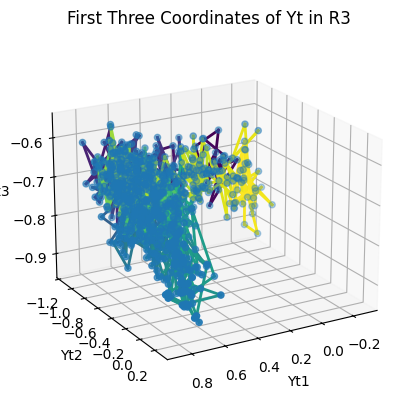

In [193]:
# Getting first three coordinates
yt_cropped = yt[:,:3]


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
pts = np.column_stack((yt_cropped[:, 0], yt_cropped[:, 2], yt_cropped[:, 1]))
cmap = plt.cm.viridis
norm = plt.Normalize(0, len(pts) - 2)

for i in range(len(pts) - 1):
    ax.plot(
        pts[i:i+2, 0],
        pts[i:i+2, 1],
        pts[i:i+2, 2],
        color=cmap(norm(i)),
        linewidth=2,
    )
ax.scatter(yt_cropped[:, 0], yt_cropped[:, 2], yt_cropped[:, 1], s=20)
ax.set_xlabel('Yt1')
ax.set_ylabel('Yt2')
ax.set_zlabel('Yt3')
ax.set_title('First Three Coordinates of Yt in R3')
ax.view_init(elev=20, azim=60)
plt.show()


This looks nothing like the plot on the sphere

# 2.3.  Recovery of the latent state via diffusion map
Finding the optimal bandwidth with the Coifman, Lafon rule

In [173]:
%matplotlib inline

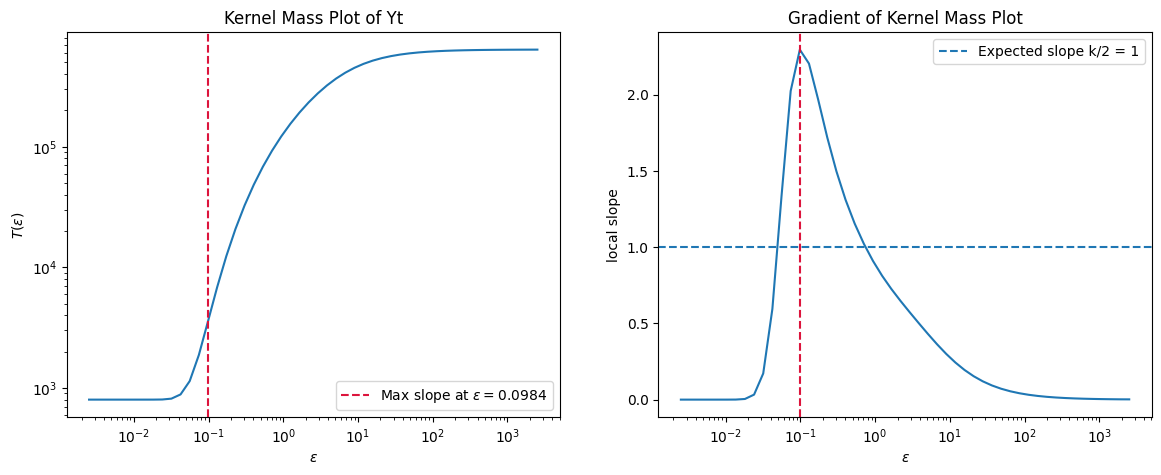

0.09844766478903341

In [197]:
def kernel_mass(D, eps_grid):
    '''
    Returns a list of kernel masses for each bandwidth epsilon
    given a distance matrix and an array of bandwidths

    args:
        D: matrix of squared distances Dij = ||xi - xj||^2
        eps_grid: array of bandwidth values
    returns:
        T_eps: List of kernel masses for each bandwidth
    '''

    T_eps = []

    for epsilon in eps_grid:
        T = np.sum(np.exp(-D / epsilon))
        T_eps.append(T)

    return T_eps



def plot_kernel_mass(X, title="Kernel Mass Plot", ax=None, plot=True):

    # Calculate squared distances between xi xj
    d = sp.spatial.distance.pdist(X)**2
    D = sp.spatial.distance.squareform(d)
    d_med = np.median(d)

    eps_grid = np.logspace(
        np.log10(d_med) - 3,
        np.log10(d_med) + 3,
        50
    )
    T_eps = kernel_mass(D, eps_grid)

    log_eps = np.log(eps_grid)
    log_T = np.log(T_eps)
    slope = np.gradient(log_T, log_eps)
    max_slope_idx = np.argmax(slope)
    eps_at_max_slope = eps_grid[max_slope_idx]

    if plot:
        if ax is not None:
            ax.loglog(eps_grid, T_eps)
            ax.axvline(eps_at_max_slope, linestyle="--", color="crimson", label=fr"Max slope at $\varepsilon={eps_at_max_slope:.3g}$")
            ax.set_title(title)
            ax.set_xlabel(r"$\varepsilon$")
            ax.set_ylabel(r"$T(\varepsilon)$")
            ax.legend()
        else:
            fig, (ax1, ax2) = plt.subplots(1,2)
            # Plotting the kernel mass plot
            ax1.loglog(eps_grid, T_eps)
            ax1.axvline(eps_at_max_slope, linestyle="--", color="crimson", label=fr"Max slope at $\varepsilon={eps_at_max_slope:.3g}$")
            ax1.set_title(title)
            ax1.set_xlabel(r"$\varepsilon$")
            ax1.set_ylabel(r"$T(\varepsilon)$")
            ax1.legend()
            # Plotting the gradient
            ax2.semilogx(eps_grid, slope)
            ax2.axvline(eps_at_max_slope, linestyle="--", color="crimson")
            ax2.axhline(1, linestyle="--", label="Expected slope k/2 = 1")
            ax2.set_xlabel(r"$\varepsilon$")
            ax2.set_ylabel("local slope")
            ax2.set_title("Gradient of Kernel Mass Plot")
            fig.set_figheight(5)
            fig.set_figwidth(14)
            plt.legend()
            plt.show()

    return eps_at_max_slope

plot_kernel_mass(yt, title="Kernel Mass Plot of Yt")

The linear region looks to be for $\varepsilon \in [0.09, 0.2]$, I will check below

In [195]:
def log_polyfit(x, y, deg=1):
    '''
    Returns the gradient and intercept of the linear 
    approximation of (log(x), log(y))
    '''
    log_x = np.log10(x)
    log_y = np.log10(y)

    m, c = np.polyfit(log_x, log_y, deg=deg)

    return m, c

# region of epsilon grid for linear behaviour
eps_grid = np.logspace(np.log10(0.07), np.log10(0.2), 40)
# Computing the kernel mass for this region
d = sp.spatial.distance.pdist(yt)**2
D = sp.spatial.distance.squareform(d)
T_eps = kernel_mass(D, eps_grid)
# Computing the slope of the linear region
m_sr, c_sr = log_polyfit(eps_grid, T_eps)
print(f'Linear regime Gradient for embedded data: {m_sr:.2f}')

Linear regime Gradient for embedded data: 2.22


This is not correct if the intrinsic dimension is 2. Maybe this is due to the nosie?  

I got rid of the noise and the gradient never reached 1, how does this make sense?

The X coordinates themselves don't even give a gradient of 1.

I will carry on by choosing $\varepsilon^\star=0.145$

In [175]:
EPS = 0.134

In [176]:
%matplotlib inline

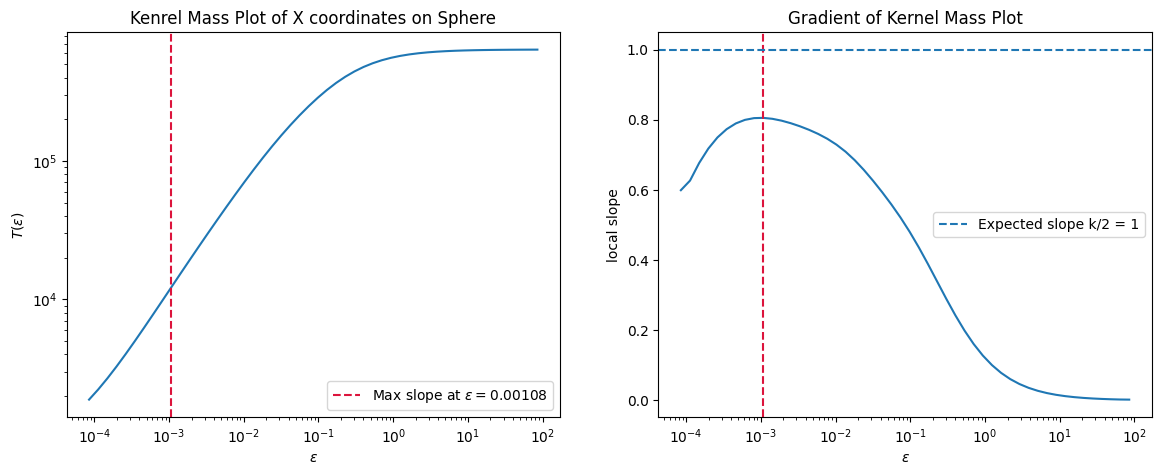

0.0010759271071871719

In [198]:
plot_kernel_mass(X, title="Kenrel Mass Plot of X coordinates on Sphere")

### Using the embedding function from diffusion.ipynb

In [178]:
def embedding(X, epsilon=None, alpha=0.5, k=2, transition_matrix=False, eigen=False):
    # Distance matrix
    d = sp.spatial.distance.pdist(X)
    D = sp.spatial.distance.squareform(d) ** 2

    # Gaussian affinity matrix
    if epsilon is None:
        epsilon = np.mean(D)
    W = np.exp(-D / epsilon)

    # Normalised affinity matrix
    q = np.sum(W, axis=1)
    W_a = W / np.outer(np.power(q, alpha), np.power(q, alpha))

    # Transition Matrix
    P = W_a / np.sum(W_a, axis=1, keepdims=True)

    # Compute eigenvalues
    n = P.shape[0]
    if n <= 5000:
        w, v = np.linalg.eig(P)
        imag_max = np.max(np.abs(np.imag(w)))
        tol = 1e-12
        if imag_max > tol:
            print("Significant complex eigenvalues (max imag):", imag_max)
        else:
            w = w.real
            v = v.real
    else:
        w, v = sp.sparse.linalg.eigs(P)
        imag_max = np.max(np.abs(np.imag(w)))
        tol = 1e-12
        if imag_max > tol:
            print("Significant complex eigenvalues (max imag):", imag_max)
        else:
            w = w.real
            v = v.real
            
    # Sort the eigenvalues
    idx = np.argsort(w)[::-1]
    w, v = w[idx], v[:, idx]

    # Embedding
    w_psi = w[1:k+1]
    v_psi = v[:, 1:k+1]

    Psi = v_psi * w_psi

    if transition_matrix and eigen:
        return Psi, P, w, v
    elif transition_matrix:
        return Psi, P
    elif eigen:
        return Psi, w, v
    
    return Psi
    

In [179]:
# Choosing k=4 means that I can see results for
# k = 1, ..., 4 without rerunning the function
Psi_Y, w, v = embedding(yt, epsilon=EPS, alpha=1, k=4, eigen=True)

w = w[1:]

gaps = w[:-1] - w[1:]

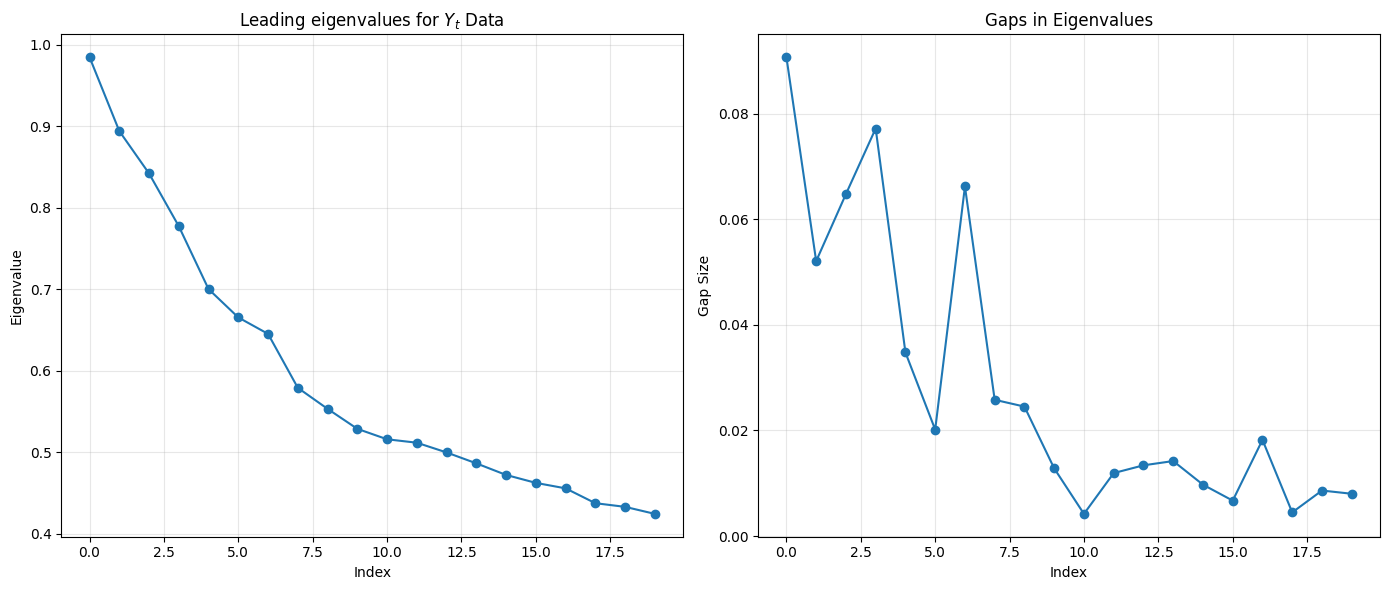

In [181]:
fig, (ax1, ax2) = plt.subplots(1,2)
fig.set_figheight(6)
fig.set_figwidth(14)

ax1.plot(w[:20], marker='o')
ax1.set_title('Leading eigenvalues for $Y_t$ Data')
ax1.set_xlabel('Index')
ax1.set_ylabel('Eigenvalue')
ax1.grid(True, alpha=0.3)

ax2.plot(gaps[:20], marker='o')
ax2.set_title('Gaps in Eigenvalues')
ax2.set_xlabel('Index')
ax2.set_ylabel('Gap Size')
ax2.grid(True, alpha=0.3)

plt.tight_layout()

This would suggest that $k=1$. Most of the time, for different $X$, the eigenvalues suggest that $k>2$.

For the first generation of $y_t$ for this specific datacloud $X$, I found $k=2$ with the spectral analysis. However, since then all the generations of $y_t$ (with the same $X$) have given $k=1$.

The intrinsic dimension estimate with spectral analysis are very dependent on the noise in each step of the process to create $y_t$.

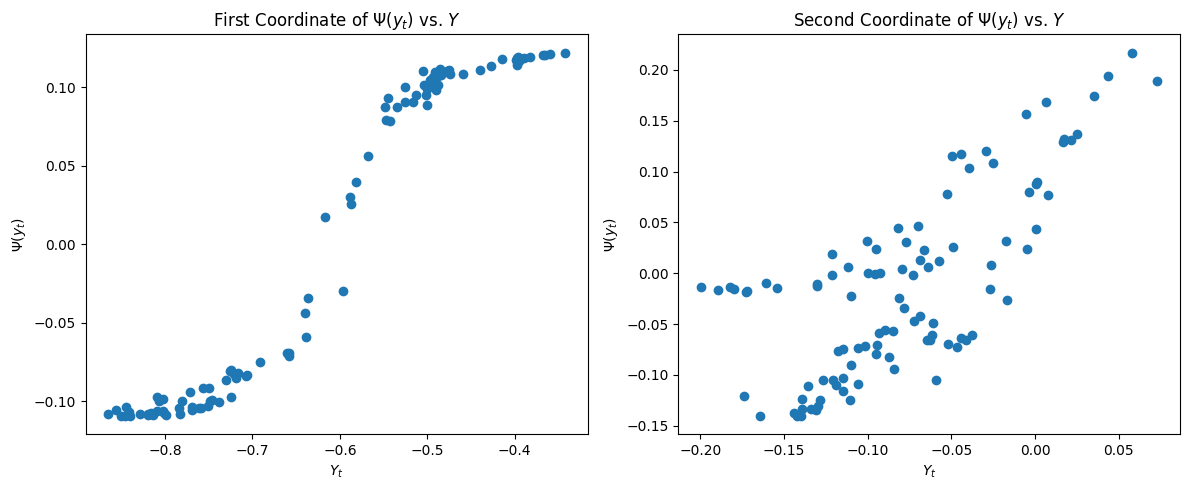

In [183]:
fig, (ax1, ax2) = plt.subplots(1,2)
fig.set_figheight(5)
fig.set_figwidth(12)

ax1.scatter(Y[:,0], Psi_Y[:,0])
ax1.set_title(r"First Coordinate of $\Psi(y_t)$ vs. $Y$")
ax1.set_xlabel(r"$Y_t$")
ax1.set_ylabel(r"$\Psi(y_t)$")

ax2.scatter(Y[:,1], Psi_Y[:,1])
ax2.set_title(r"Second Coordinate of $\Psi(y_t)$ vs. $Y$")
ax2.set_xlabel(r"$Y_t$")
ax2.set_ylabel(r"$\Psi(y_t)$")


plt.tight_layout()
plt.show()

### Fitting Procrustes alignment

In [184]:
Y_proc, Psi_proc, disparity = procrustes(Y, Psi_Y[:, :2])
print(f'Residual error: {disparity}')

Residual error: 0.2667537144725588


I have not worked through this all properly. I am experimenting with changing the parameters in the OU process. That changes things a lot, but not entierly sure why. Some OU paths stay in a line on the sphere rather than exploring the 2 dimensions of the sphere, this makes a big difference to the plots in the validation section of 2.3

# 2.4 Maximum likelihood estimation of the OU parameters

In [186]:
# Procrustes-aligned 
Y_tilde = Psi_proc

# Residuals
r = Y_tilde[1:] - np.exp(-kappa*dt)*Y_tilde[:-1]

# We want the residuals to have zero mean and cov = sig^2/2kappa (1-e^2kappa dt)I_2
# 



### Plotting same stuff for different $X$ to see how it changes

In [146]:
def plot_3d_points(X):

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    pts = np.column_stack((X[:, 0], X[:, 2], X[:, 1]))
    cmap = plt.cm.viridis
    norm = plt.Normalize(0, len(pts) - 2)

    for i in range(len(pts) - 1):
        ax.plot(
            pts[i:i+2, 0],
            pts[i:i+2, 1],
            pts[i:i+2, 2],
            color=cmap(norm(i)),
            linewidth=2,
        )
    ax.scatter(X[:, 0], X[:, 2], X[:, 1], s=20)
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('X3')
    ax.set_title('Coordinates X on S2 in R3')
    ax.view_init(elev=20, azim=60)
    plt.show()

def plot_eigenvalues(w):
    '''
    Given eigenvalues, plot the first 20 non-trivial ones
    and plot the corresponding gaps between them
    '''
    w = w[1:]
    gaps = w[:-1] - w[1:]

    fig, (ax1, ax2) = plt.subplots(1,2)
    fig.set_figheight(6)
    fig.set_figwidth(14)

    ax1.plot(w[:20], marker='o')
    ax1.set_title('Leading eigenvalues for $Y_t$ Data')
    ax1.set_xlabel('Index')
    ax1.set_ylabel('Eigenvalue')
    ax1.grid(True, alpha=0.3)

    ax2.plot(gaps[:20], marker='o')
    ax2.set_title('Gaps in Eigenvalues')
    ax2.set_xlabel('Index')
    ax2.set_ylabel('Gap Size')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()


def plot_psi_vs_y(Y, Psi_Y):
    '''
    Plot the relationship between Psi(yt) and Yt for each coordinate
    '''

    fig, (ax1, ax2) = plt.subplots(1,2)
    fig.set_figheight(5)
    fig.set_figwidth(12)

    ax1.scatter(Y[:,0], Psi_Y[:,0])
    ax1.set_title(r"First Coordinate of $\Psi(y_t)$ vs. $Y$")
    ax1.set_xlabel(r"$Y_t$")
    ax1.set_ylabel(r"$\Psi(y_t)$")

    ax2.scatter(Y[:,1], Psi_Y[:,1])
    ax2.set_title(r"Second Coordinate of $\Psi(y_t)$ vs. $Y$")
    ax2.set_xlabel(r"$Y_t$")
    ax2.set_ylabel(r"$\Psi(y_t)$")


    plt.tight_layout()
    plt.show()

D = 100, $\sigma_\eta=0.05$

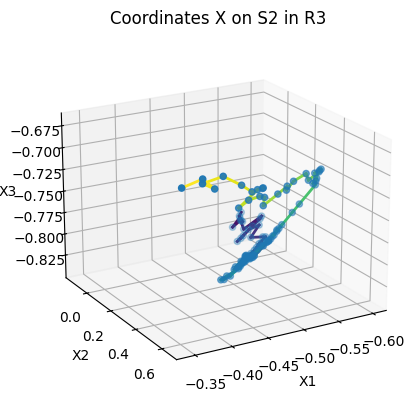

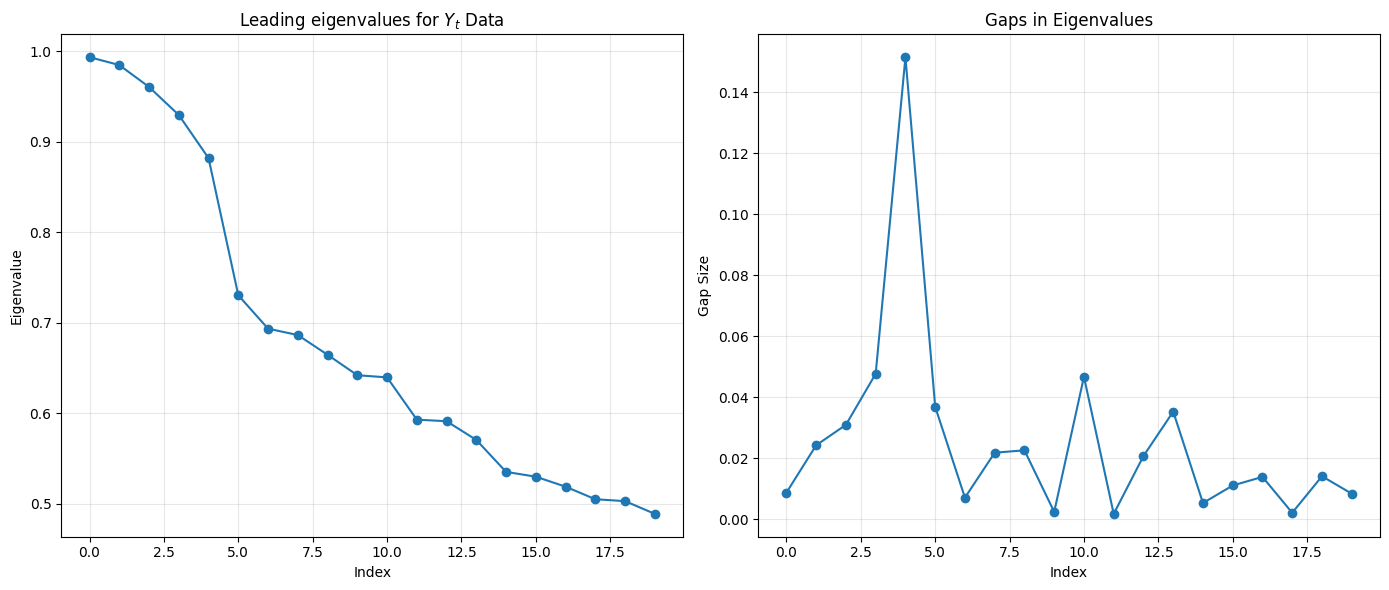

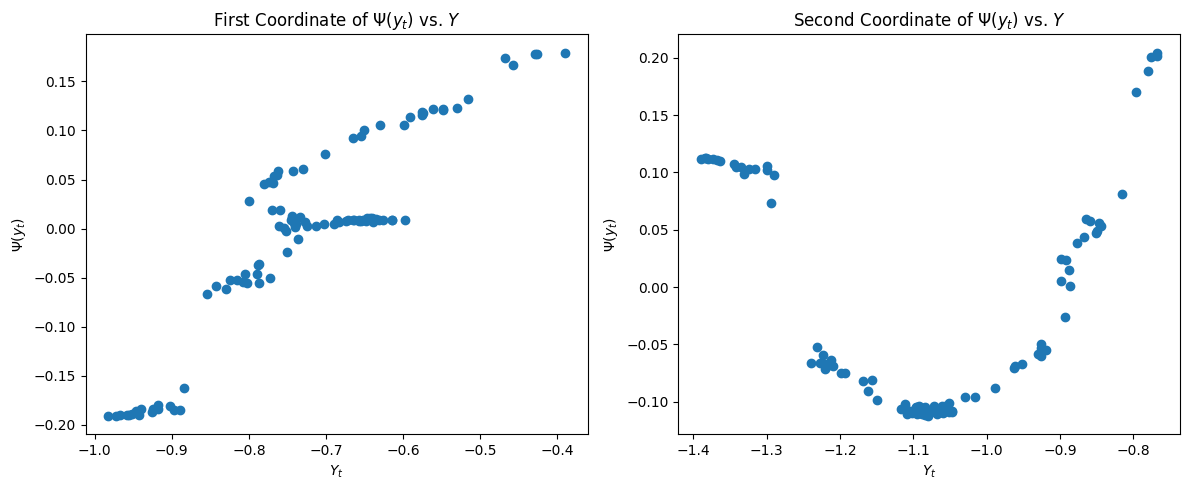

Residual error: 0.5049478935062884


In [161]:
X, Y = simulate_ou_on_sphere()
yt = embed_with_noise(X, D=100, sigma_eta=0.05)
eps = plot_kernel_mass(yt, r"D=100, $\sigma_\mu=0.1$", plot=False)
Psi_Y, w, v = embedding(yt, epsilon=eps, alpha=1, k=4, eigen=True)

plot_3d_points(X)
plot_eigenvalues(w)
plot_psi_vs_y(Y, Psi_Y)
Y_proc, Psi_proc, disparity = procrustes(Y, Psi_Y[:, :2])
print(f'Residual error: {disparity}')

D = 100, $\sigma_\eta=0.1$

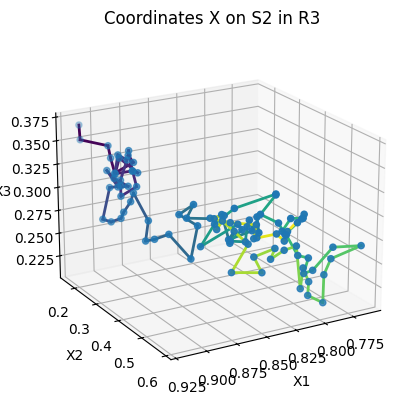

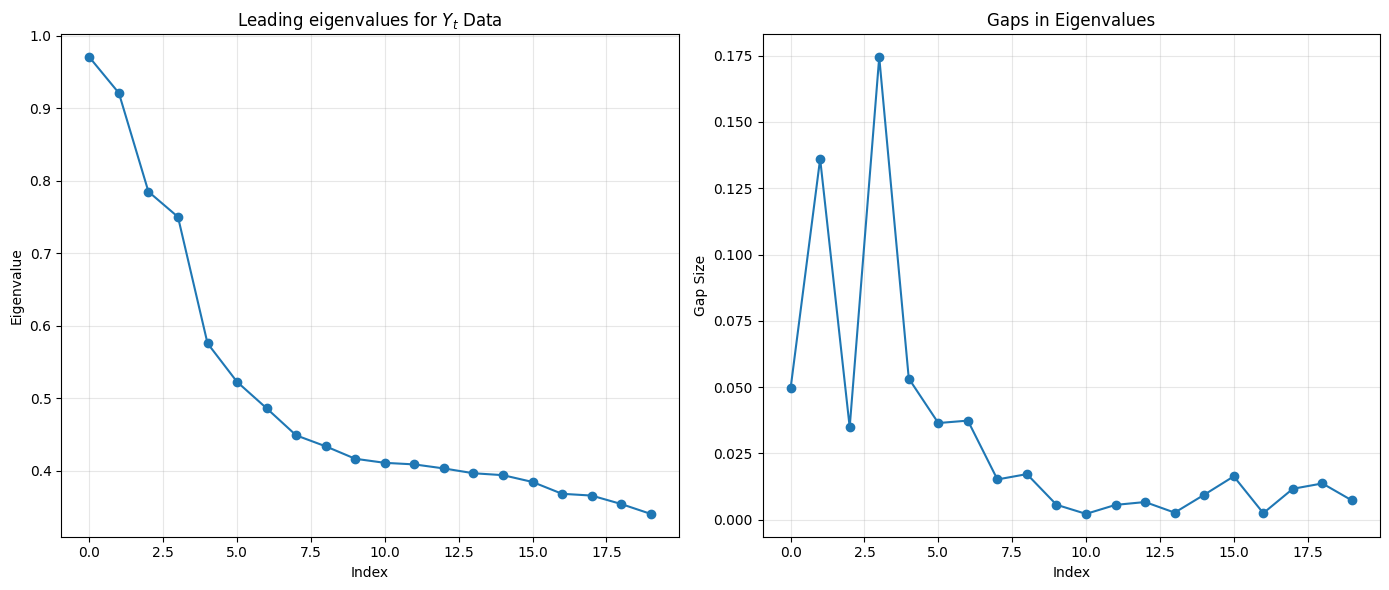

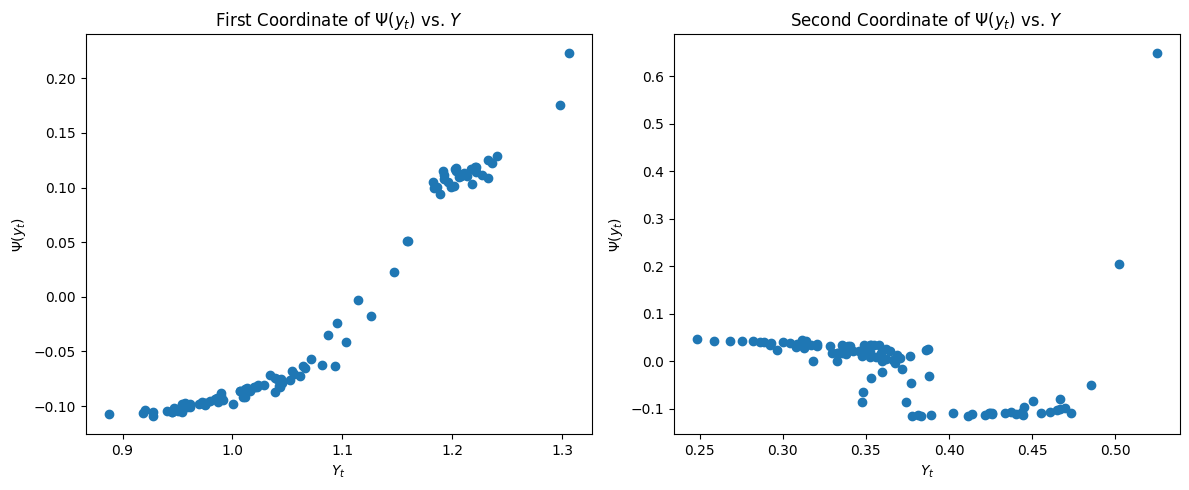

Residual error: 0.4319894045020477


In [162]:
X, Y = simulate_ou_on_sphere()
yt = embed_with_noise(X, D=100, sigma_eta=0.05)
eps = plot_kernel_mass(yt, r"D=100, $\sigma_\mu=0.1$", plot=False)
Psi_Y, w, v = embedding(yt, epsilon=eps, alpha=1, k=4, eigen=True)

plot_3d_points(X)
plot_eigenvalues(w)
plot_psi_vs_y(Y, Psi_Y)
Y_proc, Psi_proc, disparity = procrustes(Y, Psi_Y[:, :2])
print(f'Residual error: {disparity}')

D = 100, $\sigma_\eta=0.2$

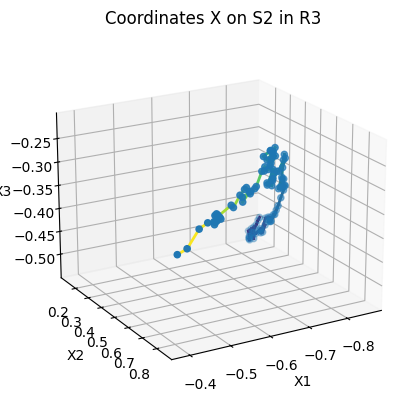

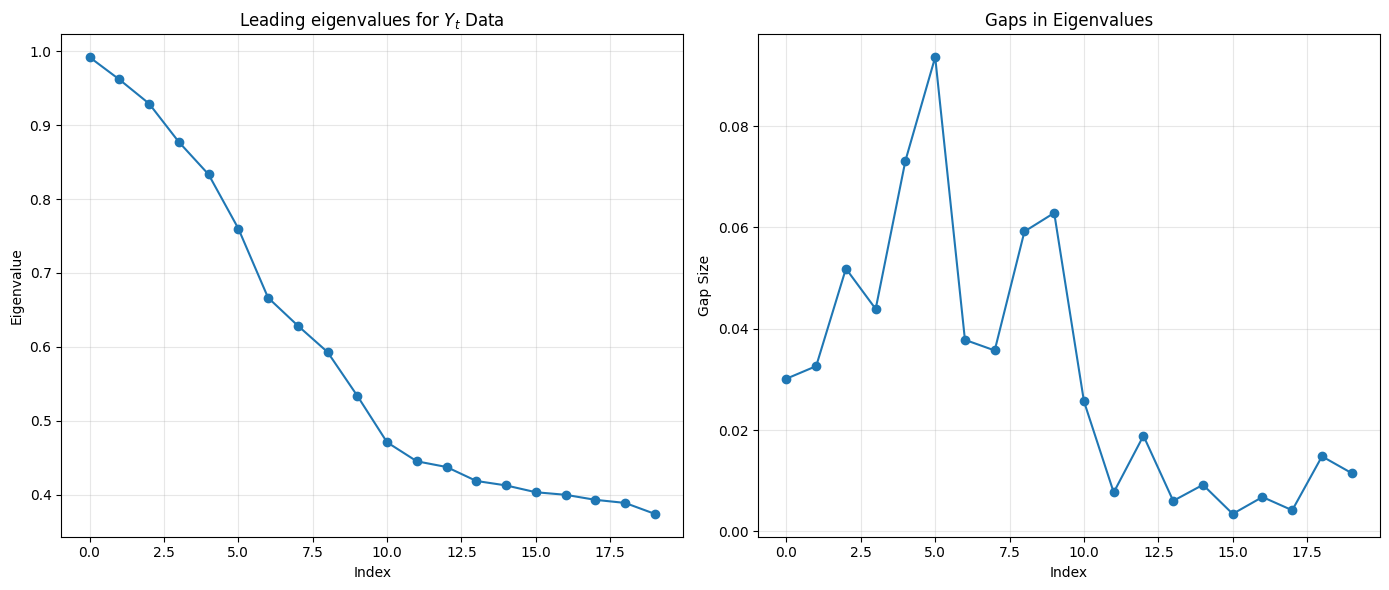

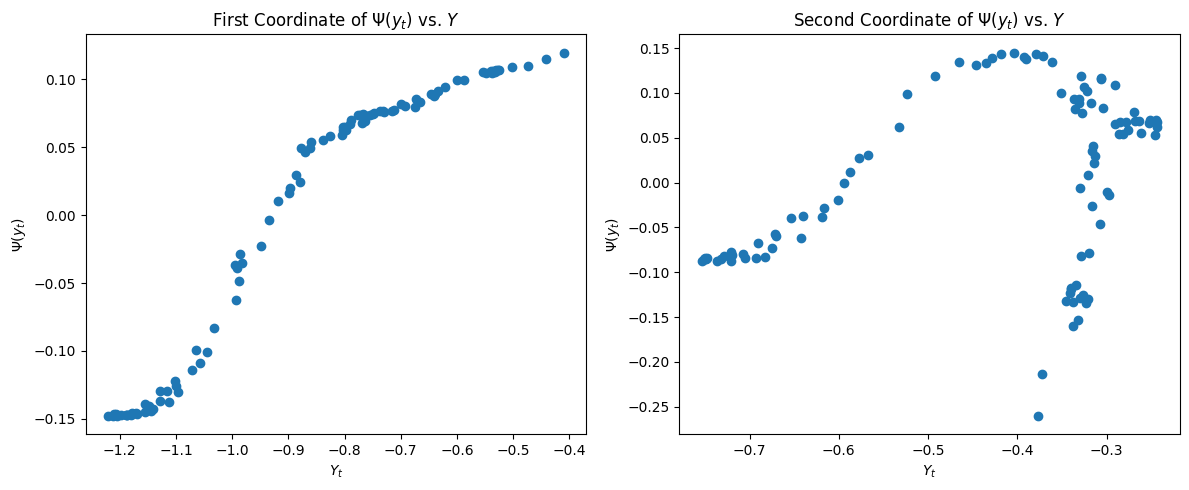

Residual error: 0.2731638439609886


In [163]:
X, Y = simulate_ou_on_sphere()
yt = embed_with_noise(X, D=100, sigma_eta=0.05)
eps = plot_kernel_mass(yt, r"D=100, $\sigma_\mu=0.1$", plot=False)
Psi_Y, w, v = embedding(yt, epsilon=eps, alpha=1, k=4, eigen=True)

plot_3d_points(X)
plot_eigenvalues(w)
plot_psi_vs_y(Y, Psi_Y)
Y_proc, Psi_proc, disparity = procrustes(Y, Psi_Y[:, :2])
print(f'Residual error: {disparity}')

D = 75, $\sigma_\eta=0.05$

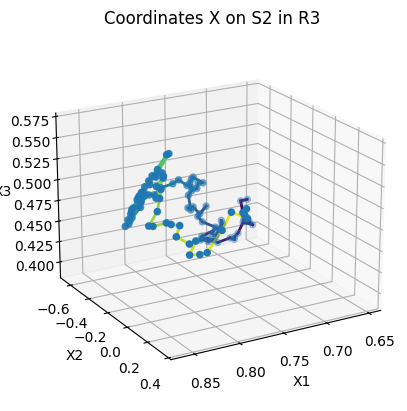

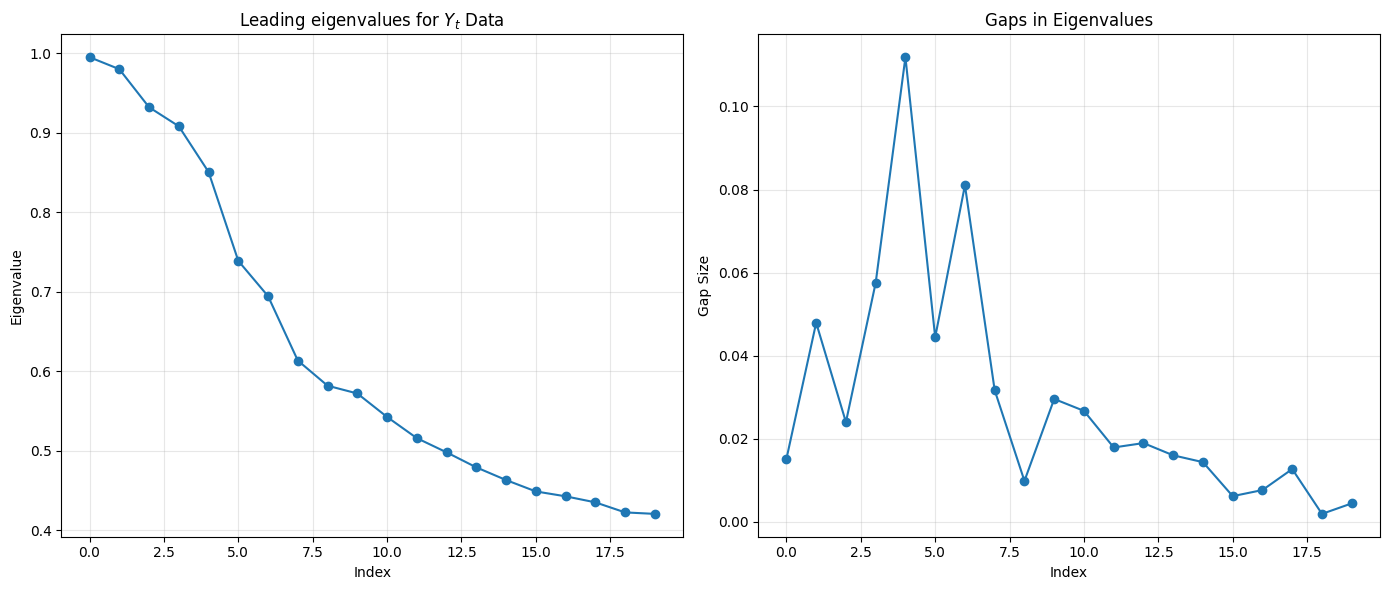

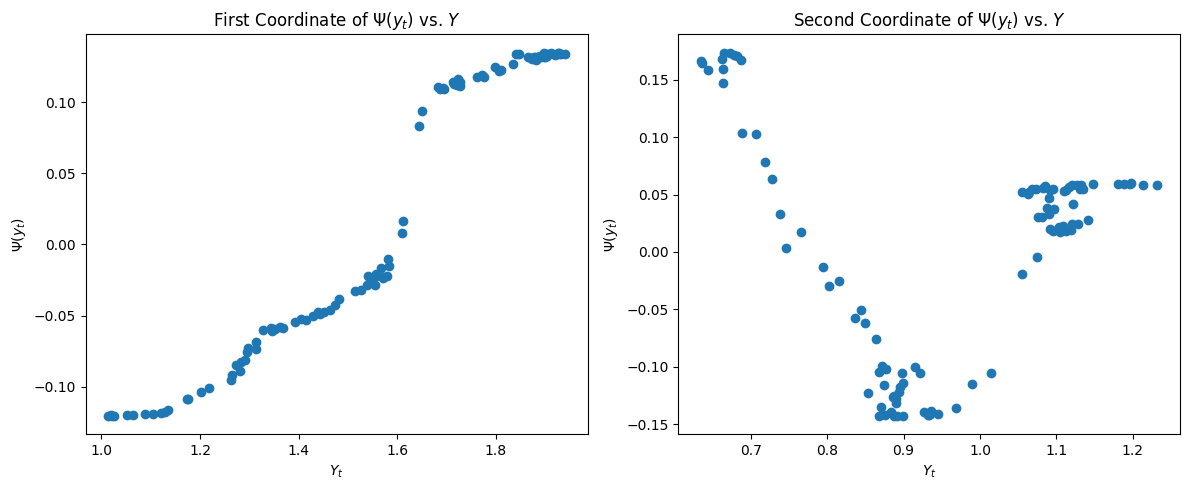

Residual error: 0.533005808952182


In [164]:
X, Y = simulate_ou_on_sphere()
yt = embed_with_noise(X, D=100, sigma_eta=0.05)
eps = plot_kernel_mass(yt, r"D=100, $\sigma_\mu=0.1$", plot=False)
Psi_Y, w, v = embedding(yt, epsilon=eps, alpha=1, k=4, eigen=True)

plot_3d_points(X)
plot_eigenvalues(w)
plot_psi_vs_y(Y, Psi_Y)
Y_proc, Psi_proc, disparity = procrustes(Y, Psi_Y[:, :2])
print(f'Residual error: {disparity}')

D = 75, $\sigma_\mu=0.1$

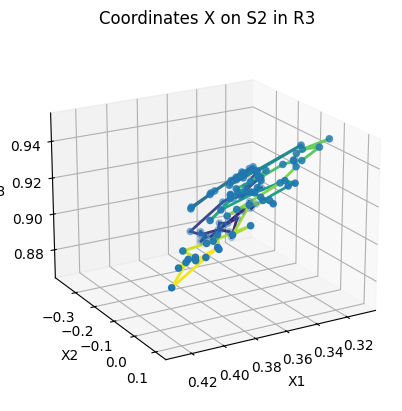

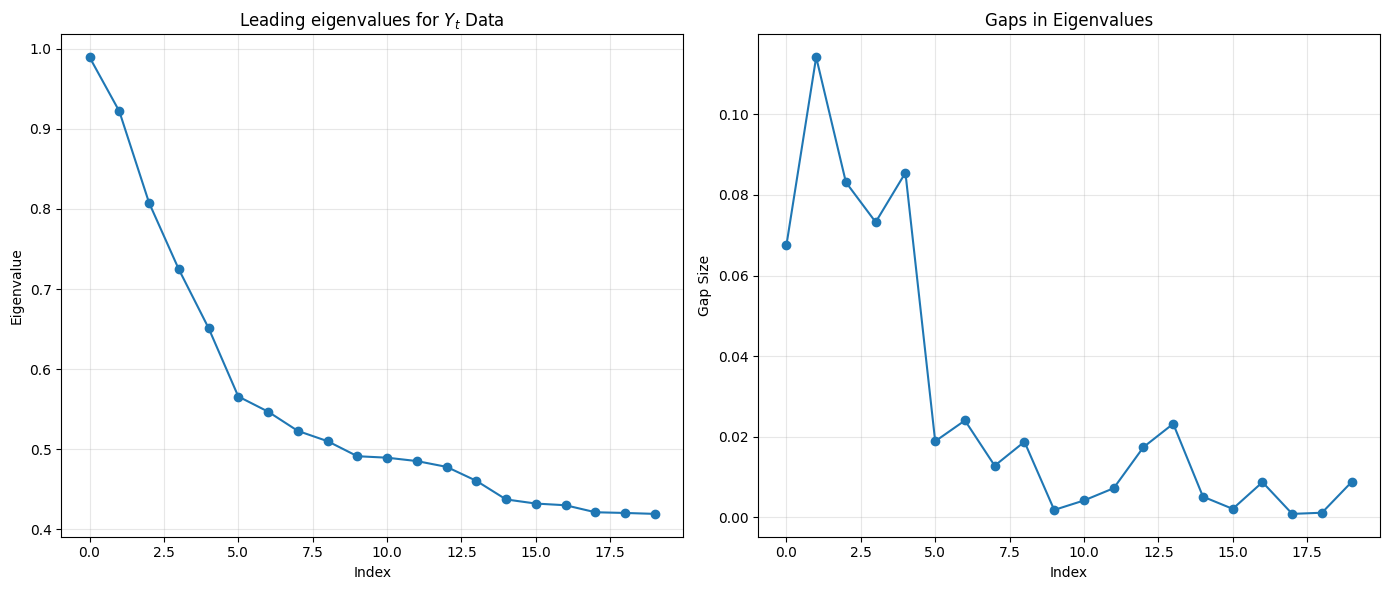

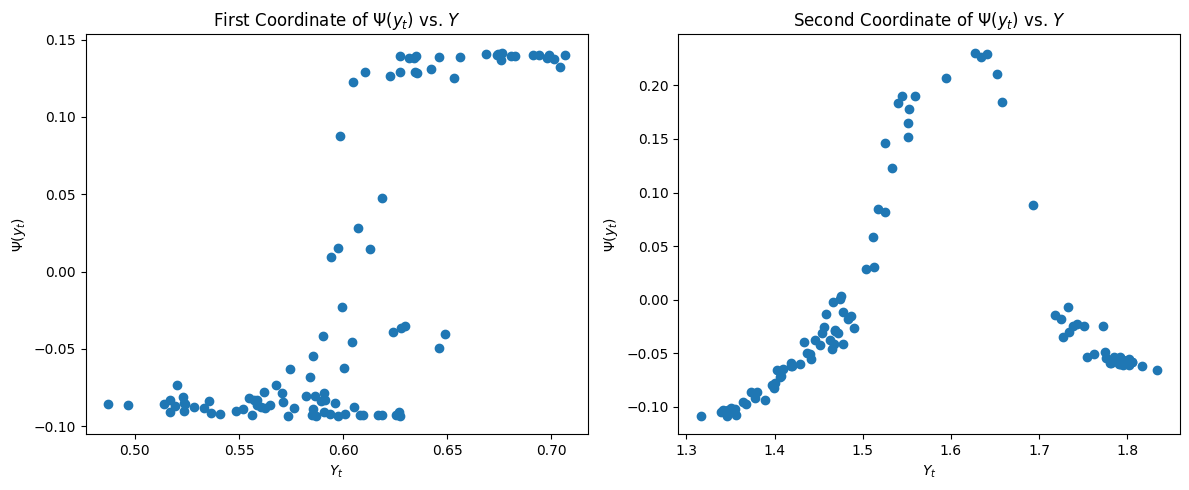

Residual error: 0.4621108865026734


In [165]:
X, Y = simulate_ou_on_sphere()
yt = embed_with_noise(X, D=100, sigma_eta=0.05)
eps = plot_kernel_mass(yt, r"D=100, $\sigma_\mu=0.1$", plot=False)
Psi_Y, w, v = embedding(yt, epsilon=eps, alpha=1, k=4, eigen=True)

plot_3d_points(X)
plot_eigenvalues(w)
plot_psi_vs_y(Y, Psi_Y)
Y_proc, Psi_proc, disparity = procrustes(Y, Psi_Y[:, :2])
print(f'Residual error: {disparity}')

D = 75, $\sigma_\mu=0.2$

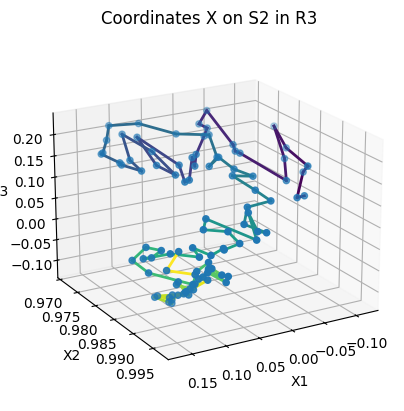

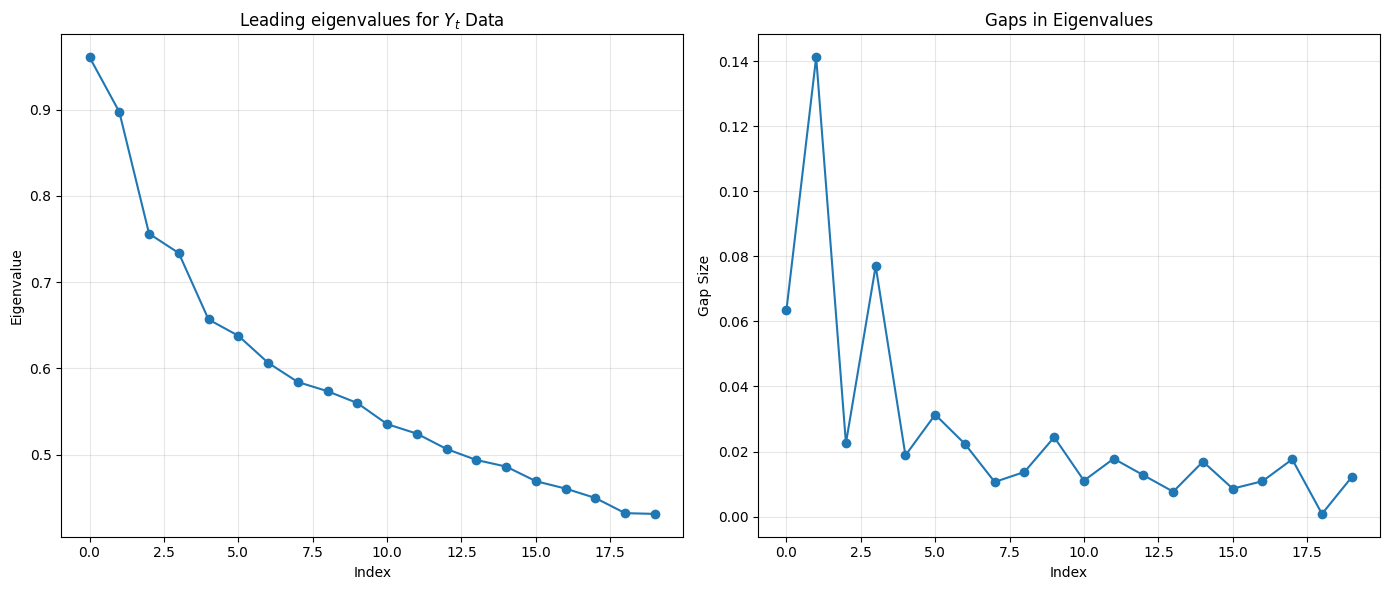

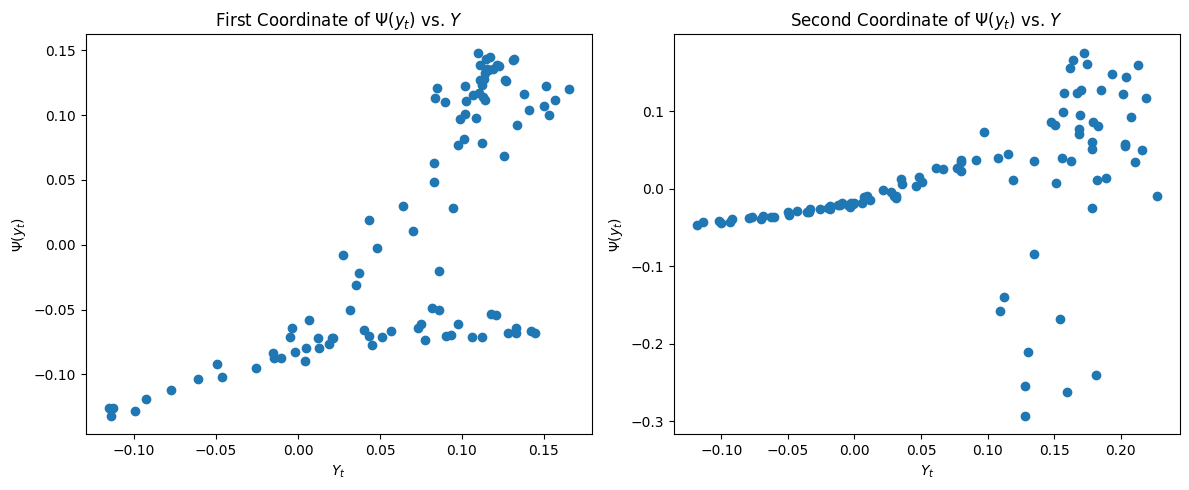

Residual error: 0.16580985201160658


In [166]:
X, Y = simulate_ou_on_sphere()
yt = embed_with_noise(X, D=100, sigma_eta=0.05)
eps = plot_kernel_mass(yt, r"D=100, $\sigma_\mu=0.1$", plot=False)
Psi_Y, w, v = embedding(yt, epsilon=eps, alpha=1, k=4, eigen=True)

plot_3d_points(X)
plot_eigenvalues(w)
plot_psi_vs_y(Y, Psi_Y)
Y_proc, Psi_proc, disparity = procrustes(Y, Psi_Y[:, :2])
print(f'Residual error: {disparity}')